### Download YOLO Formatted file of Non-Seasonal Vegetable Dataset


In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="J1rWUvuwvKwOyLI5ooEK")
project = rf.workspace("sanjana-kazi-supti-ymhu2").project("non-seasonal-vegetable-detection-yms0u")
version = project.version(3)
dataset = version.download("yolov12")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.3


Extracting Dataset Version Zip to Non-Seasonal-Vegetable-Detection-3 in yolov12:: 100%|██████████| 9606/9606 [00:01<00:00, 9331.55it/s] 


### Install ultralytics supervision and Roboflow. Then check for the CUDA

In [2]:
!pip install ultralytics --no-deps
import ultralytics
ultralytics.checks()

Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6563.3/8062.4 GB disk)


In [3]:
!pip install pycocotools tqdm


In [4]:
import os
import shutil
import json
from pathlib import Path
import yaml
from ultralytics import YOLO

In [5]:
# !pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2 ultralytics pyyaml pandas matplotlib opencv-python


## Visualize Some Annotated images

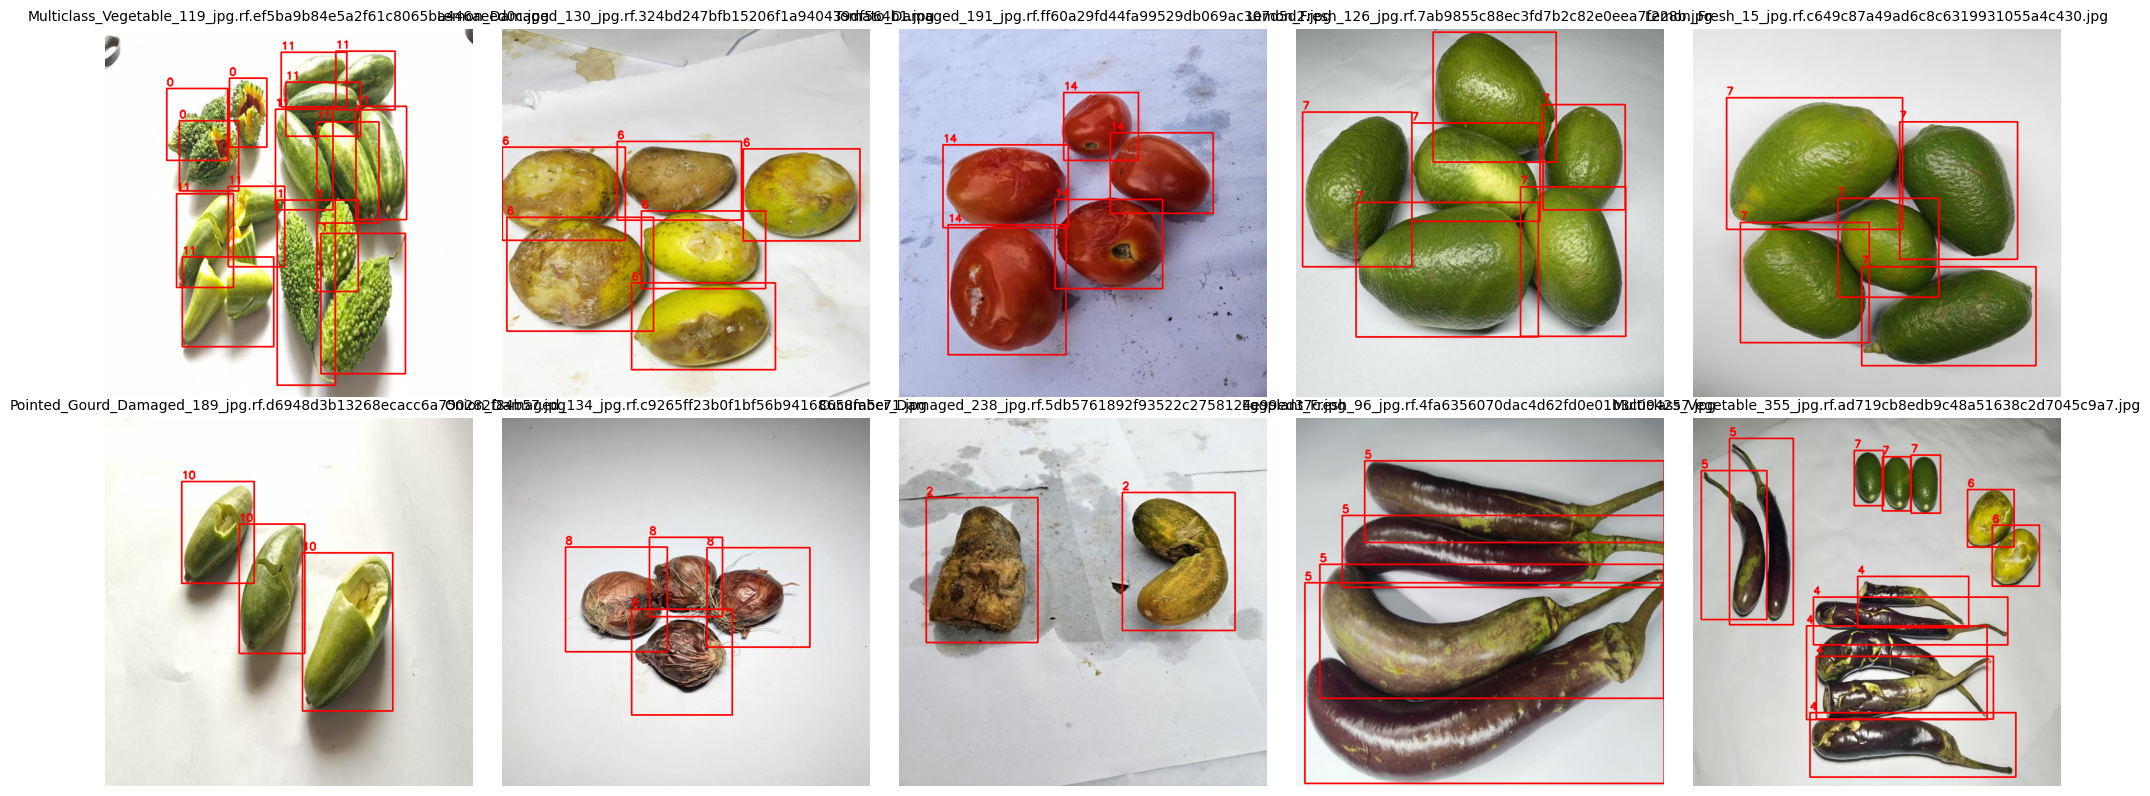

In [6]:
import cv2
import matplotlib.pyplot as plt
import random

WORK = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3")

# ----------------------------------------------------------------------------
# 2. Visualize Converted YOLO Annotations
# ----------------------------------------------------------------------------

def draw_yolo_bbox(img_path, label_path):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if not label_path.exists():
        return image  # No label file

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x_c, y_c, bw, bh = map(float, line.strip().split())
            x1 = int((x_c - bw / 2) * w)
            y1 = int((y_c - bh / 2) * h)
            x2 = int((x_c + bw / 2) * w)
            y2 = int((y_c + bh / 2) * h)
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image, str(int(cls)), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return image

# Pick 10 random images from the converted train split
img_dir = WORK / "train" / "images"
lbl_dir = WORK / "train" / "labels"
img_files = list(img_dir.glob("*.jpg"))
sample_files = random.sample(img_files, min(10, len(img_files)))

# Plot 2 rows of 5 images
plt.figure(figsize=(20, 8))
for idx, img_path in enumerate(sample_files):
    label_path = lbl_dir / f"{img_path.stem}.txt"
    img = draw_yolo_bbox(img_path, label_path)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
!pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2
!pip install ultralytics --no-deps
import ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ultralytics 8.3.235 requires ultralytics-thop>=2.0.18, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.25.2 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.25.2 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 1.25.2 which is incompatible.
datasets 4.4.1 requires pyarrow>=21.0.0, b

# **YOLO V11**

## 1. Train

In [8]:
# ----------------------------------------------------------------------------
# 2. Train YOLOv11
# ----------------------------------------------------------------------------

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11s.pt")

# Train the model on the COCO8 example dataset for 100 epochs
#results = model.train(data="coco8.yaml", epochs=100, imgsz=640)
model.train(
    data    = str(WORK/"data.yaml"),
    epochs  = 50,
    imgsz   = 640,
    batch   = 12,
    val     = True,
    save_json=True,
    project = str(WORK),
    name    = "yolov11_train",
    device  = 0
)

Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

invalid value encountered in less
invalid value encountered in less


                   all        717       3615      0.984      0.989      0.989      0.847
  Bitter_Gourd_Damaged         49        222      0.986      0.976      0.993      0.882
    Bitter_Gourd_Fresh         52        161      0.965      0.994      0.995      0.888
      Cucumber_Damaged         63        254      0.996      0.992      0.995       0.84
        Cucumber_Fresh         64        244      0.994          1      0.992      0.845
      Eggplant_Damaged         67        246       0.98      0.986      0.991      0.898
        Eggplant_Fresh         66        227      0.964      0.944      0.978      0.871
         Lemon_Damaged         66        220       0.99      0.991      0.992       0.89
           Lemon_Fresh         65        238      0.973      0.987      0.979      0.905
         Onion_Damaged         59        228      0.962      0.996      0.962      0.646
           Onion_Fresh         59        242      0.999          1      0.995      0.716
 Pointed_Gourd_Damage

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f208544fcd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

### Visualization of the Loss Curve

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


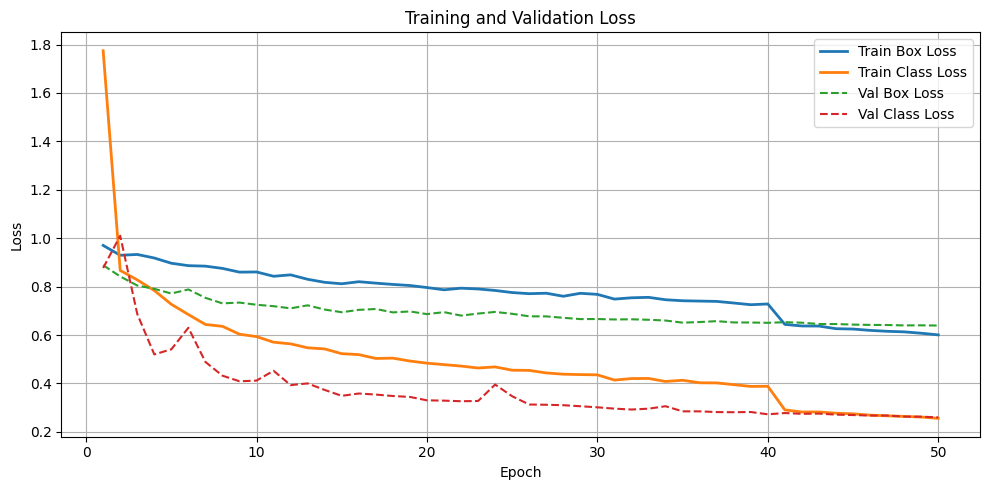

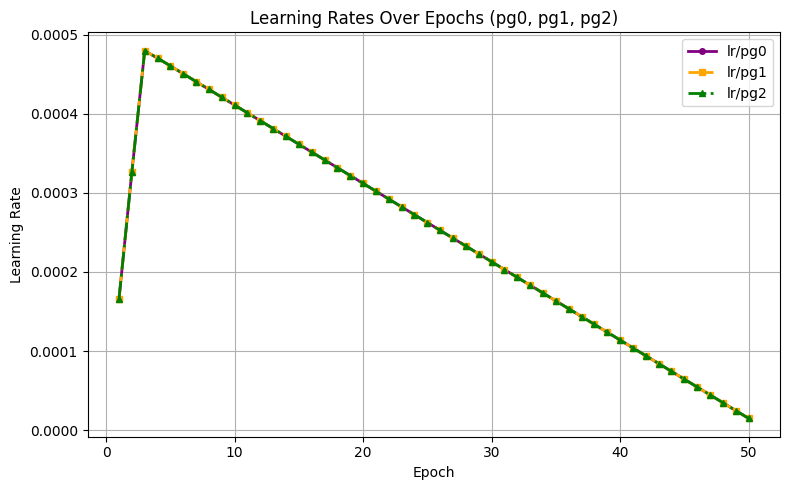

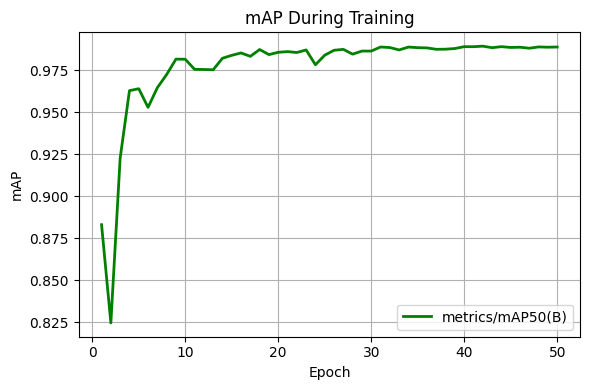

In [9]:
# ----------------------------------------------------------------------------
# 3. Visualize Training Metrics
# ----------------------------------------------------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Path to results.csv
results_path = WORK / "yolov11_train" / "results.csv"

# Load CSV
df = pd.read_csv(results_path)

# Show available columns
print("Available columns:", df.columns.tolist())

# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss", linewidth=2)
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Class Loss", linewidth=2)
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="--")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Class Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

lr_columns = [col for col in df.columns if col.startswith("lr/pg")]
colors = ['purple', 'orange', 'green']
styles = ['-', '--', '-.']
markers = ['o', 's', '^']

if lr_columns:
    plt.figure(figsize=(8, 5))
    for idx, col in enumerate(lr_columns):
        plt.plot(
            df["epoch"], df[col],
            label=col,
            color=colors[idx % len(colors)],
            linestyle=styles[idx % len(styles)],
            marker=markers[idx % len(markers)],
            markersize=4,
            linewidth=2
        )
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rates Over Epochs (pg0, pg1, pg2)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No learning rate columns found.")


# Plot mAP Curve (0.5 IoU)
map_keys = ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]  # version dependent
map_column = next((key for key in map_keys if key in df.columns), None)

if map_column:
    plt.figure(figsize=(6, 4))
    plt.plot(df["epoch"], df[map_column], label=map_column, color="green", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title("mAP During Training")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP column not found. Skipping mAP plot.")


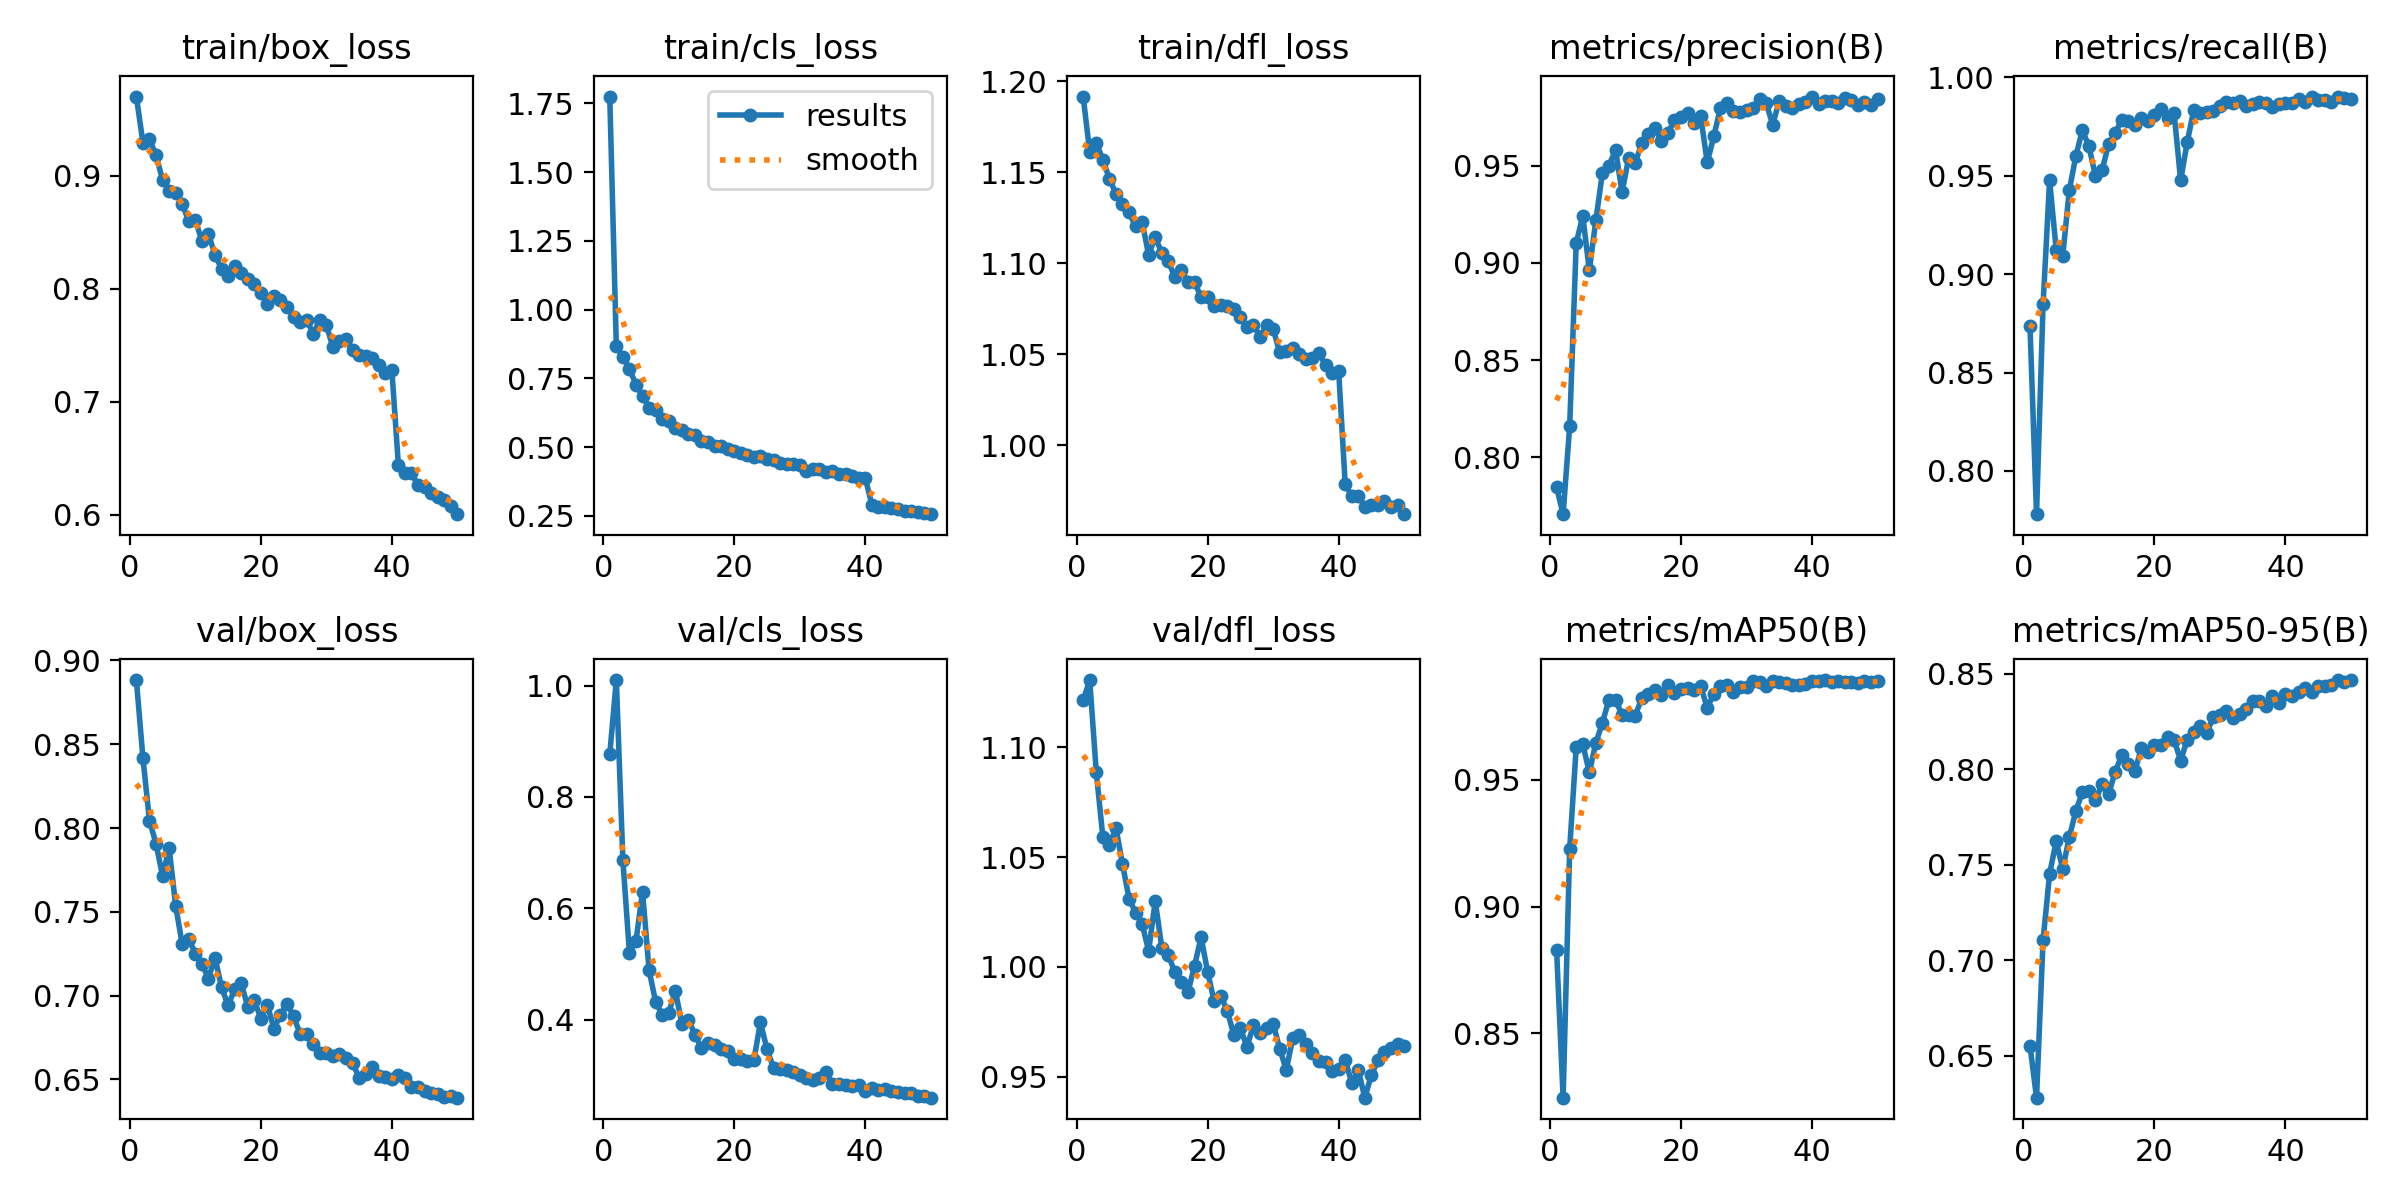

In [10]:
from PIL import Image
from IPython.display import display

results_img = WORK / "yolov11_train" / "results.png"
img = Image.open(results_img)
display(img)

## 2. VALIDATION

In [11]:
# ----------------------------------------------------------------------------
# 4. Validation Performance
# ----------------------------------------------------------------------------
val_results = model.val(
    data    = str(WORK/"data.yaml"),
    imgsz   = 640,
    batch   = 16
)
print("Validation metrics:", val_results)

Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,418,992 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 619.5±212.1 MB/s, size: 29.9 KB)
val: Scanning /kaggle/working/Non-Seasonal-Vegetable-Detection-3/valid/labels.cache... 717 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 717/717 1.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 3.7it/s 12.2s


invalid value encountered in less
invalid value encountered in less


                   all        717       3615      0.984      0.989      0.989      0.847
  Bitter_Gourd_Damaged         49        222      0.986      0.976      0.993      0.883
    Bitter_Gourd_Fresh         52        161      0.965      0.994      0.995      0.889
      Cucumber_Damaged         63        254      0.996      0.992      0.995       0.84
        Cucumber_Fresh         64        244      0.994          1      0.992      0.845
      Eggplant_Damaged         67        246       0.98      0.986      0.991      0.897
        Eggplant_Fresh         66        227      0.964      0.944      0.978       0.87
         Lemon_Damaged         66        220       0.99      0.991      0.992      0.891
           Lemon_Fresh         65        238      0.973      0.987       0.98      0.907
         Onion_Damaged         59        228      0.962      0.996      0.962      0.647
           Onion_Fresh         59        242      0.999          1      0.995      0.715
 Pointed_Gourd_Damage

## 3. TEST


In [12]:
# ----------------------------------------------------------------------------
# 5. Test Performance
# ----------------------------------------------------------------------------
test_results = model.val(
    data    = str(WORK/"data.yaml"),
    imgsz   = 640,
    batch   = 16,
    split   = "test"
)
print("Test metrics:", test_results)

Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 586.1±165.0 MB/s, size: 29.5 KB)
val: Scanning /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/labels... 721 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 721/721 1.3Kit/s 0.6s
val: New cache created: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 3.6it/s 12.8s


invalid value encountered in less
invalid value encountered in less


                   all        721       3712      0.985       0.99      0.988      0.843
  Bitter_Gourd_Damaged         66        311       0.97      0.952      0.986      0.845
    Bitter_Gourd_Fresh         69        275      0.962      0.993      0.991      0.861
      Cucumber_Damaged         55        181      0.993          1      0.995      0.829
        Cucumber_Fresh         57        198          1      0.998      0.995      0.876
      Eggplant_Damaged         58        222      0.982      0.987      0.991      0.901
        Eggplant_Fresh         55        223      0.937      0.991      0.951       0.87
         Lemon_Damaged         57        203      0.989          1       0.99      0.894
           Lemon_Fresh         57        196      0.968          1      0.987       0.92
         Onion_Damaged         60        202      0.989       0.99      0.987      0.659
           Onion_Fresh         59        219      0.993      0.977      0.985      0.676
 Pointed_Gourd_Damage

## 4. Classification Report and Confusion Matrix


image 1/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_100_jpg.rf.ab4b4565a78f60f301ca6a30d1ecea1e.jpg: 640x640 4 Bitter_Gourd_Damageds, 15.7ms
image 2/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_105_jpg.rf.55f417bf52243c7099ae25fa814b7058.jpg: 640x640 5 Bitter_Gourd_Damageds, 15.8ms
image 3/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_107_jpg.rf.740770ed4741b89502ea33fb091ac7cb.jpg: 640x640 7 Bitter_Gourd_Damageds, 15.7ms
image 4/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_10_jpg.rf.ecd59a29224212c13b6267bd24864b43.jpg: 640x640 1 Bitter_Gourd_Damaged, 15.7ms
image 5/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_117_jpg.rf.1974f15af88cd46e1fe78505c6082cb8.jpg: 640x640 7 Bitter_Gourd_Damageds, 15.7ms
image 6/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/B

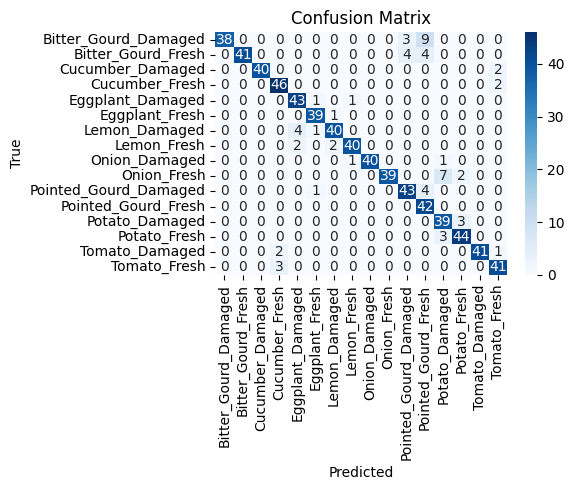

In [13]:
# ----------------------------------------------------------------------------
# 6. Generate Classification Report & Confusion Matrix
# ----------------------------------------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Run predictions on test images (stream=True saves memory)
preds = model.predict(
    source=str(WORK / "test" / "images"),
    imgsz=640,
    stream=True
)

# Get class names from the model
CLASS_NAMES = list(model.names.values())
NUM_CLASSES = len(CLASS_NAMES)

# Fix: initialize y_true and y_pred correctly
y_true = []
y_pred = []

for pred in preds:
    # Predicted class (use highest confidence box only)
    if pred.boxes is not None and len(pred.boxes.cls) > 0:
        pred_class = int(pred.boxes.cls[0].item())
        y_pred.append(pred_class)
    else:
        y_pred.append(-1)  # No prediction

    # True class from YOLO-style label file
    image_name = Path(pred.path).stem
    label_file = WORK / "test" / "labels" / f"{image_name}.txt"

    if label_file.exists():
        with open(label_file, 'r') as f:
            line = f.readline().strip()
            if line:
                true_label = int(line.split()[0])
                y_true.append(true_label)
            else:
                y_true.append(-1)  # Empty label file
    else:
        y_true.append(-1)  # Label file not found

# Remove predictions with missing true/predicted labels
filtered_true = [t for t, p in zip(y_true, y_pred) if t != -1 and p != -1]
filtered_pred = [p for t, p in zip(y_true, y_pred) if t != -1 and p != -1]

# Prepare classification report
print("\nClassification Report:")
used_labels = sorted(set(filtered_true + filtered_pred))
used_names = [CLASS_NAMES[i] for i in used_labels]

print(classification_report(
    filtered_true,
    filtered_pred,
    labels=used_labels,
    target_names=used_names,
    zero_division=0  # Prevents division by zero warning
))

# Confusion matrix
cm = confusion_matrix(filtered_true, filtered_pred, labels=used_labels)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=used_names, yticklabels=used_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


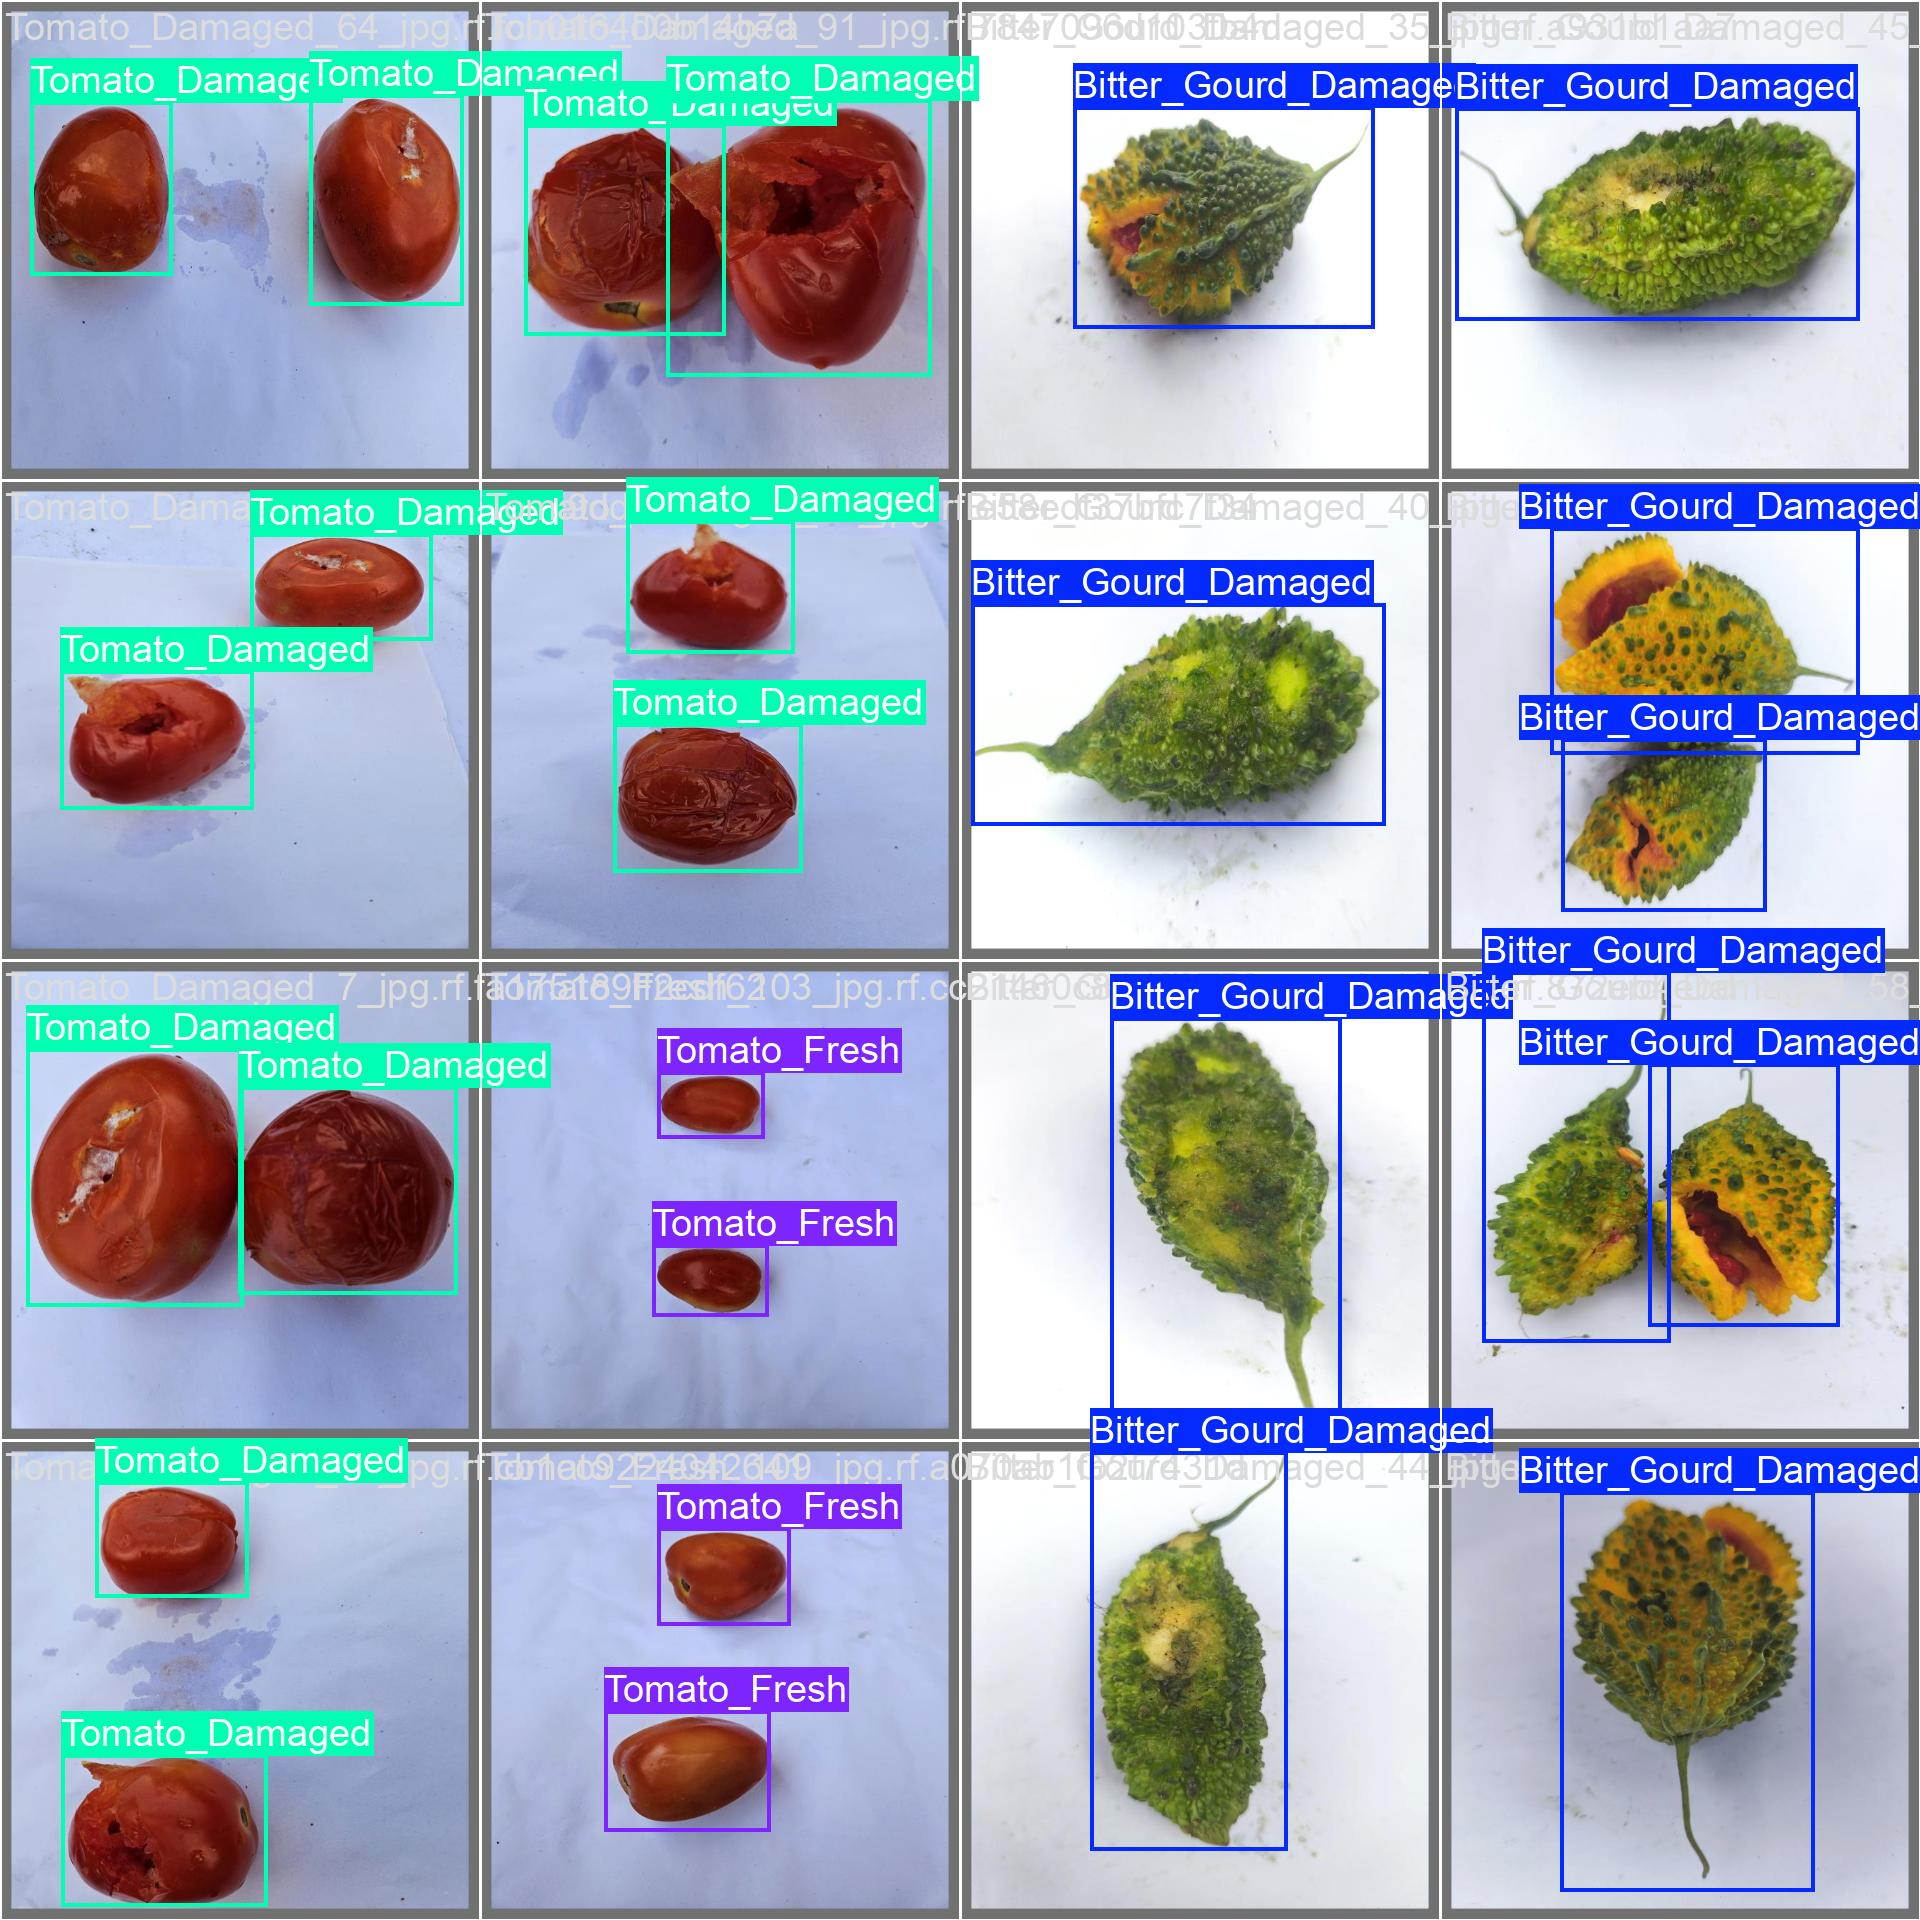

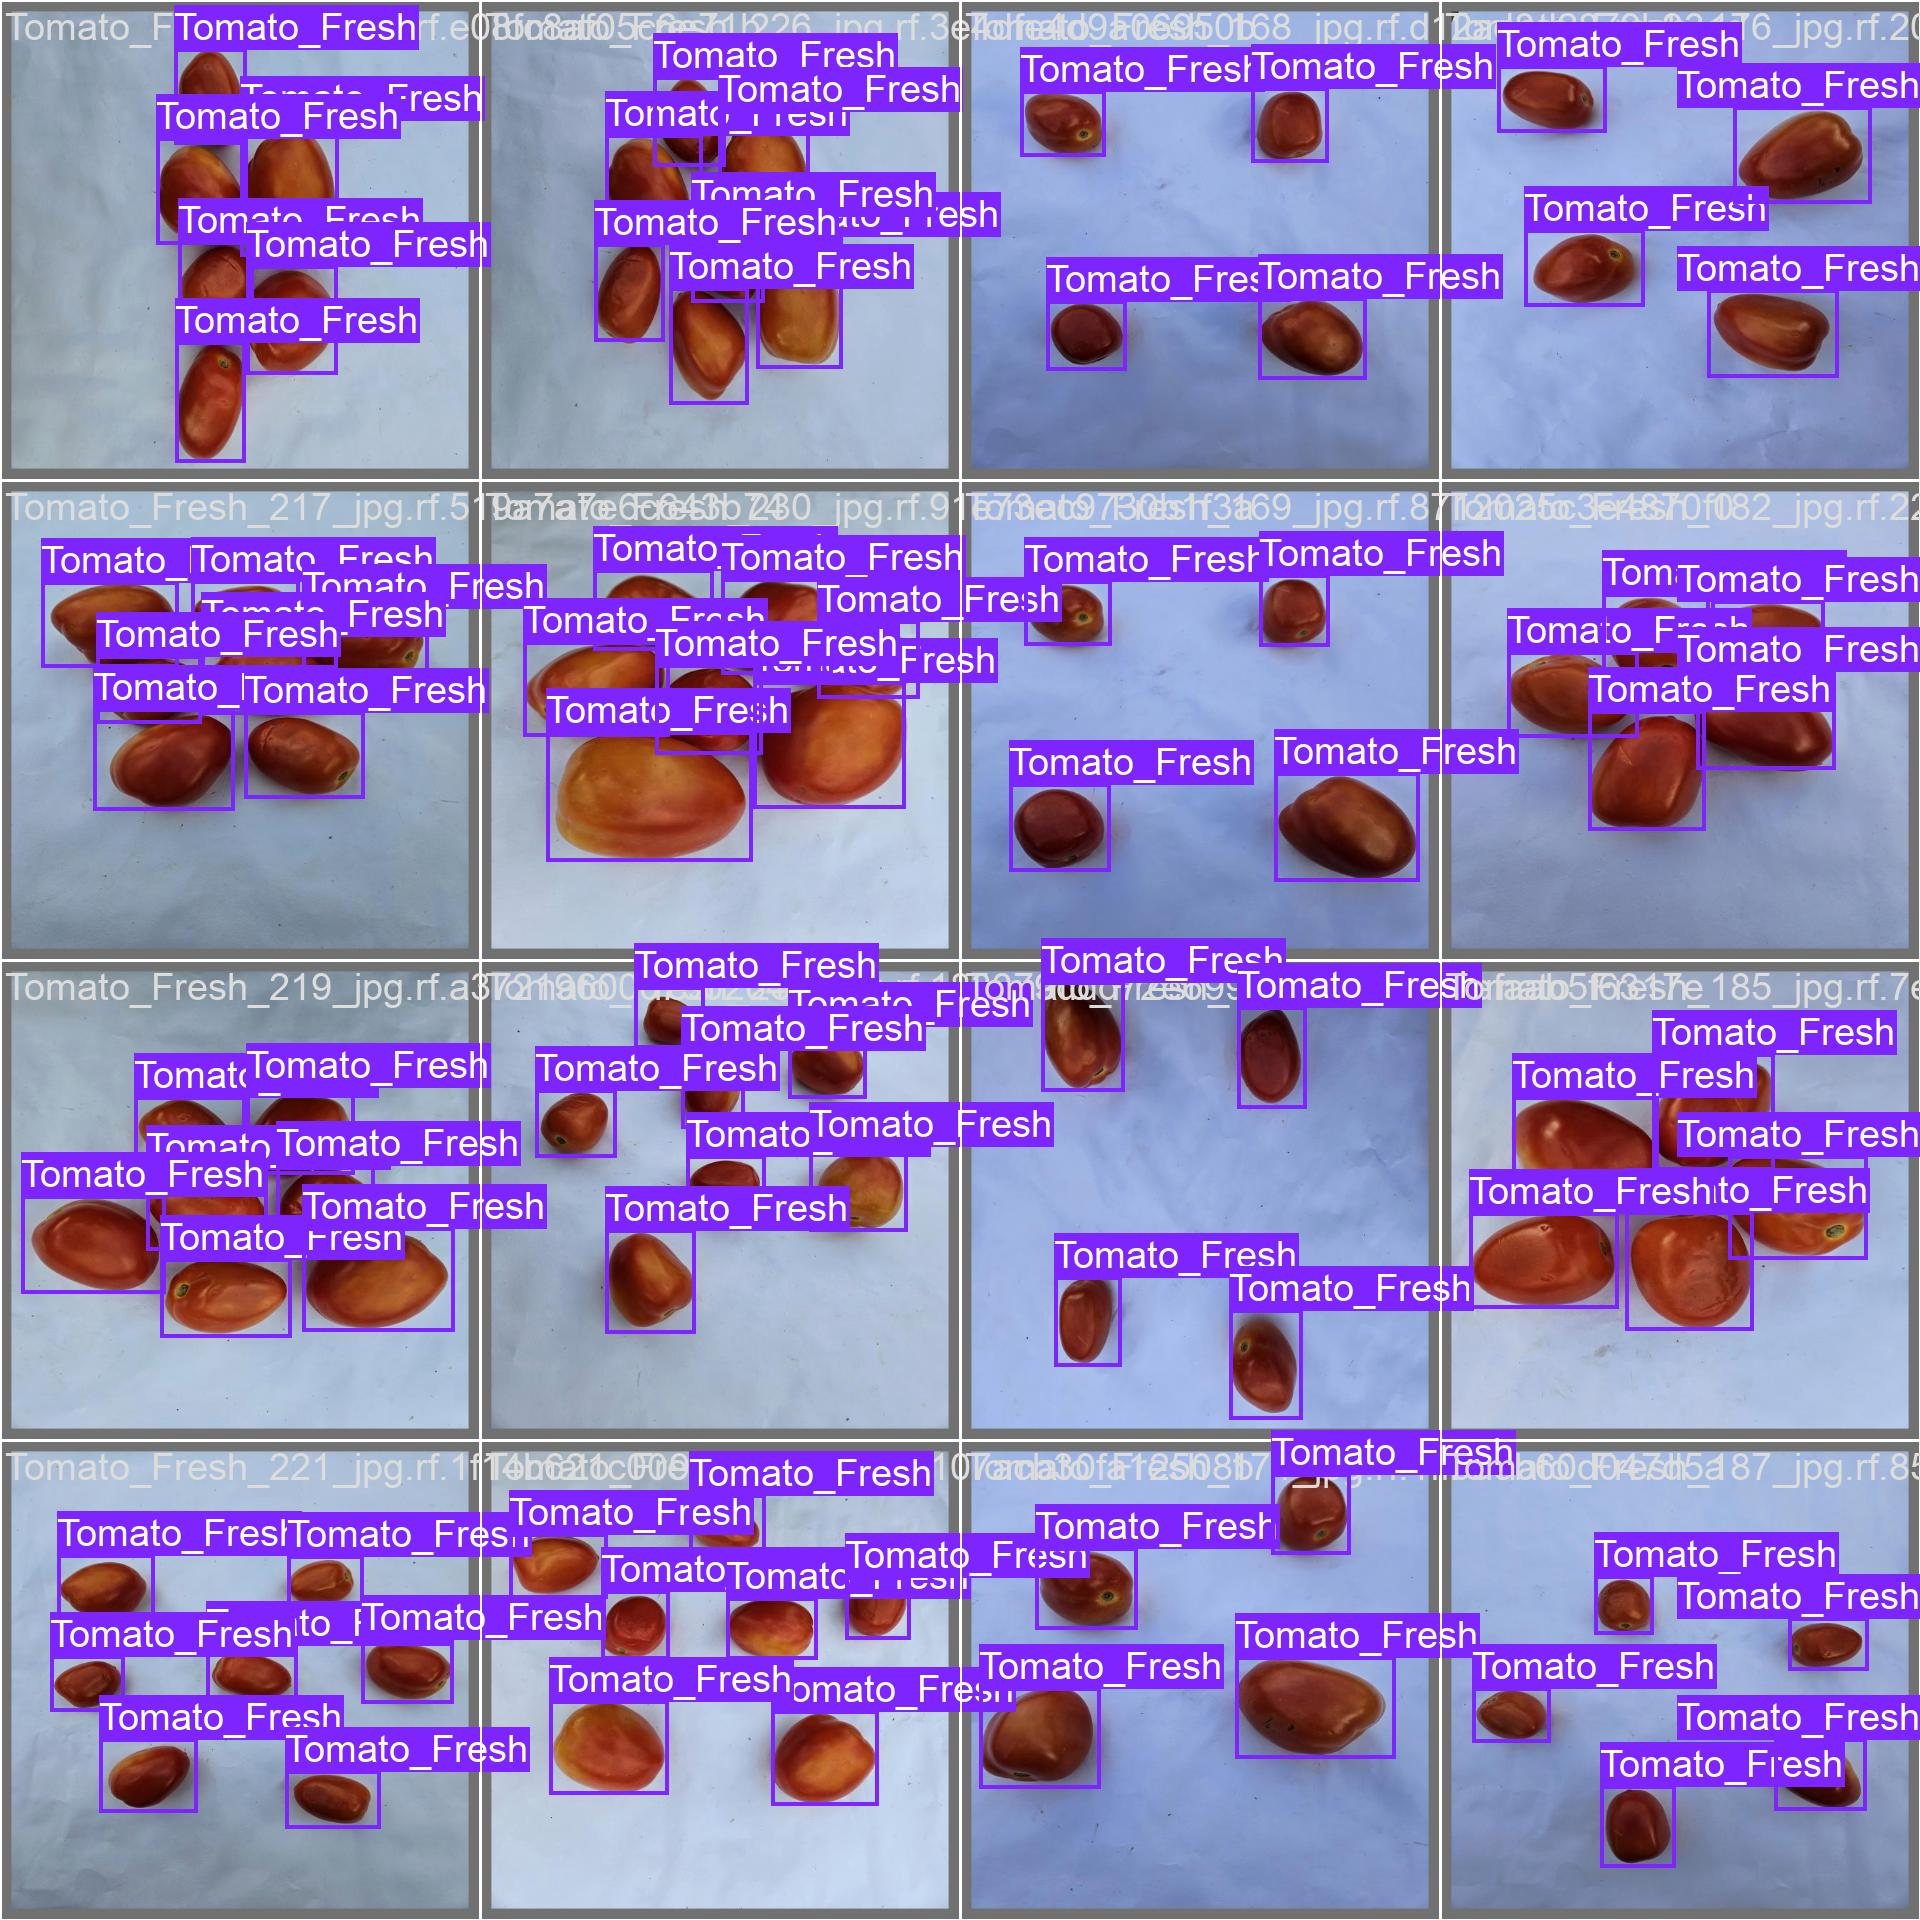

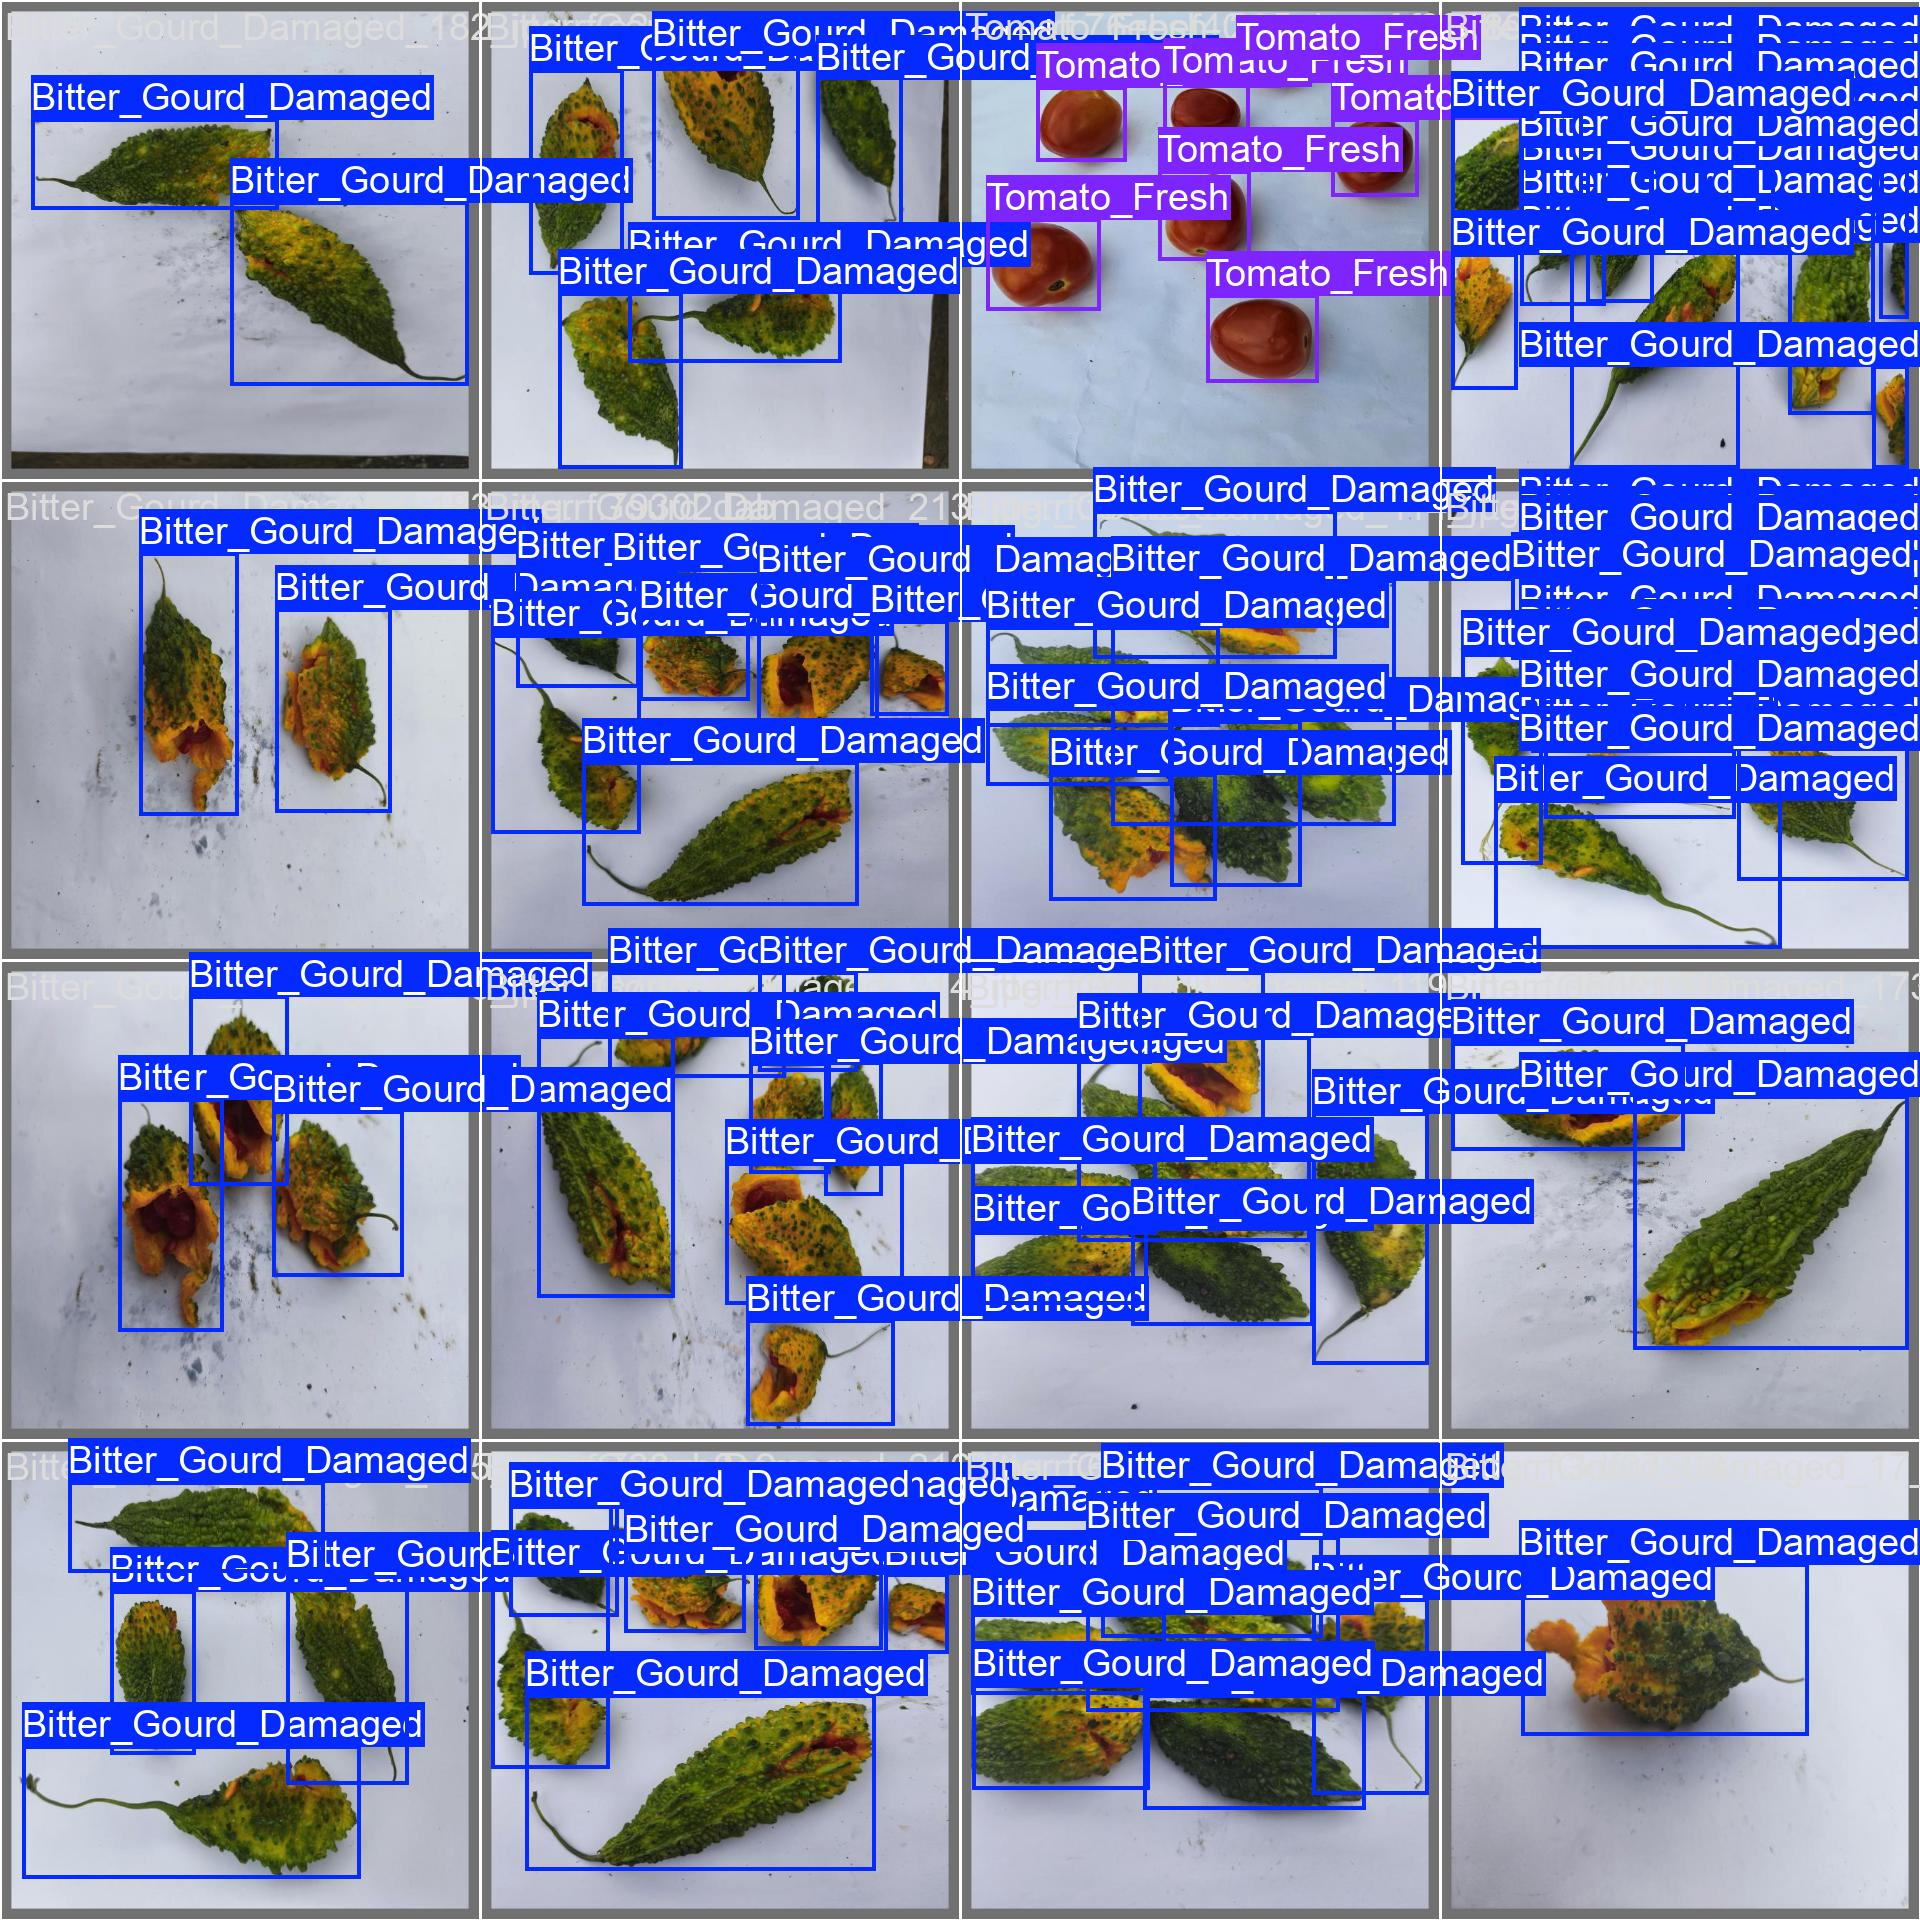

In [14]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(str(WORK / "yolov11_train")), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
	display(IPyImage(filename=img, width=600))
	print("\n")

## 5. Save the best Weights

In [15]:
latest_folder = str(WORK / "yolov11_train")

from pathlib import Path
import glob
import os

# Assuming WORK is a Path object
WORK = Path(WORK)

# Full path to the parent folder
parent_folder = WORK / "yolov11_train"

# Get the most recent folder inside 'yolov12_train'
latest_folder = max(
    [f for f in parent_folder.iterdir() if f.is_dir()],
    key=lambda x: x.stat().st_mtime
)

print(f"Latest folder: {latest_folder}")

# Now, get images inside the latest_folder
for img_path in latest_folder.glob("*.jpg"):
    print(img_path)

Latest folder: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/yolov11_train/weights


In [16]:
# ----------------------------------------------------------------------------
# 7. Save Best Weights
# ----------------------------------------------------------------------------
best_weights = WORK/"yolov11_train"/"weights"/"best.pt"
print(f"Best model saved to {best_weights}")

Best model saved to /kaggle/working/Non-Seasonal-Vegetable-Detection-3/yolov11_train/weights/best.pt


### XAI

In [17]:
!git clone https://github.com/rigvedrs/YOLO-V12-CAM.git

Cloning into 'YOLO-V12-CAM'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 168 (delta 39), reused 21 (delta 11), pack-reused 99 (from 2)
Receiving objects: 100% (168/168), 52.67 MiB | 41.94 MiB/s, done.
Resolving deltas: 100% (70/70), done.


In [18]:
!ls

Non-Seasonal-Vegetable-Detection-3  runs	yolo11s.pt
__notebook__.ipynb		    yolo11n.pt	YOLO-V12-CAM


In [19]:
!pip install ttach

import sys
sys.path.append("/kaggle/working/YOLO-V12-CAM")
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

In [20]:
import cv2
import numpy as np
model = YOLO( WORK/'yolov11_train' /'weights'/'best.pt')
model = model.cpu()

In [21]:
img = cv2.imread('/kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Multiclass_Vegetable_24_jpg.rf.8d34a92f30203f87046a973ccb024137.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [22]:
target_layers =[model.model.model[-2]]

RGB


0: 640x640 2 Cucumber_Damageds, 2 Cucumber_Freshs, 2 Tomato_Damageds, 5 Tomato_Freshs, 269.9ms
Speed: 3.1ms preprocess, 269.9ms inference, 10.5ms postprocess per image at shape (1, 3, 640, 640)


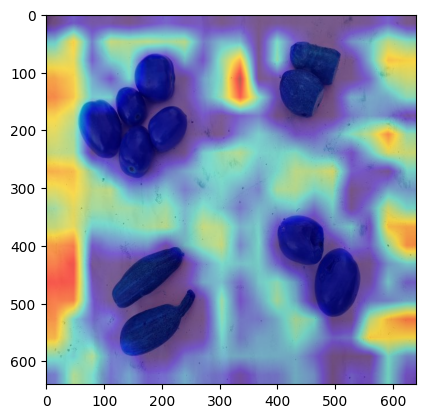

In [23]:
cam = EigenCAM(model, target_layers,task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

GrayScale

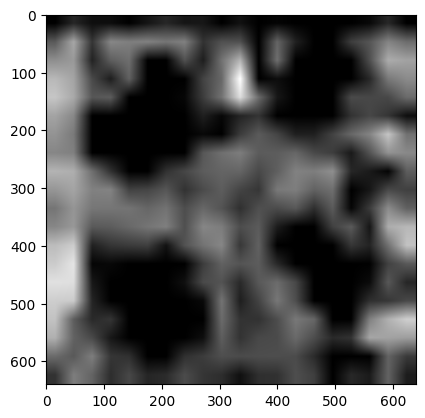

In [24]:
import matplotlib.pyplot as plt
import numpy as np
g_scale = np.stack([grayscale_cam] * 3, axis=2)
plt.imshow(g_scale)

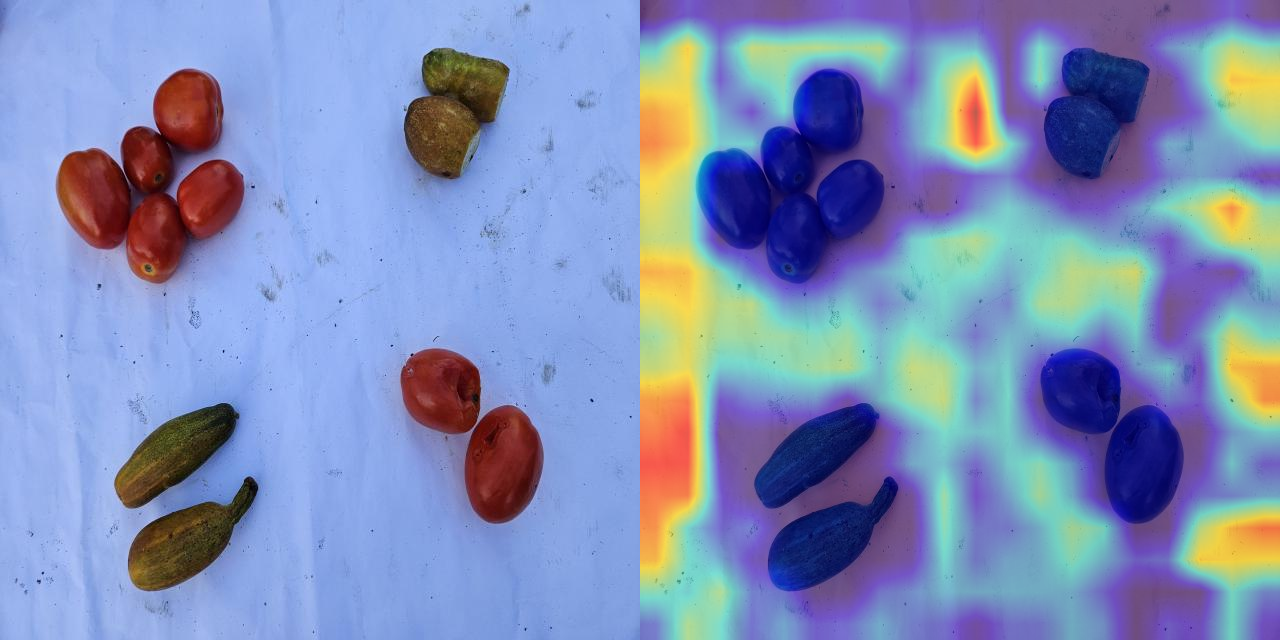

In [25]:
import cv2
from PIL import Image
im = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
Image.fromarray(np.hstack((im, cam_image)))

Model has 24 layers.
Using target layers at indices: [21, 22, 23]

0: 640x640 (no detections), 252.7ms
Speed: 3.4ms preprocess, 252.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


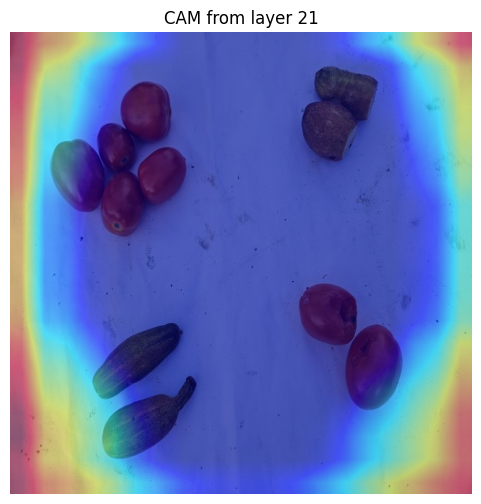


0: 640x640 (no detections), 240.3ms
Speed: 3.0ms preprocess, 240.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


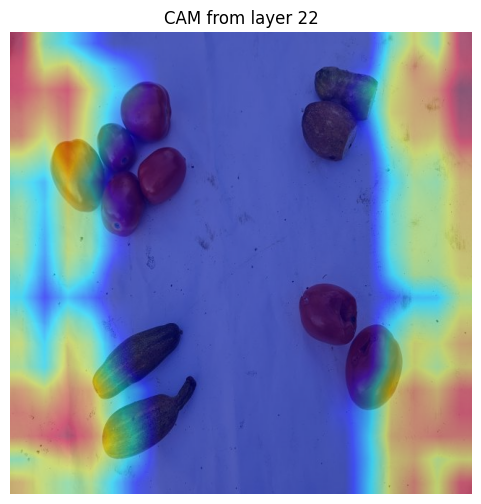


0: 640x640 (no detections), 205.0ms
Speed: 3.5ms preprocess, 205.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


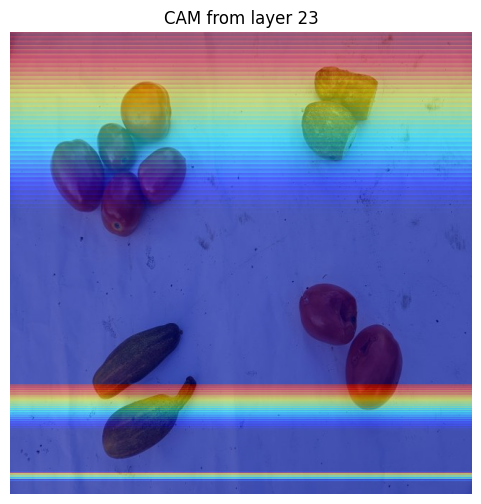


0: 640x640 2 Cucumber_Damageds, 2 Cucumber_Freshs, 4 Tomato_Damageds, 5 Tomato_Freshs, 198.0ms
Speed: 2.2ms preprocess, 198.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


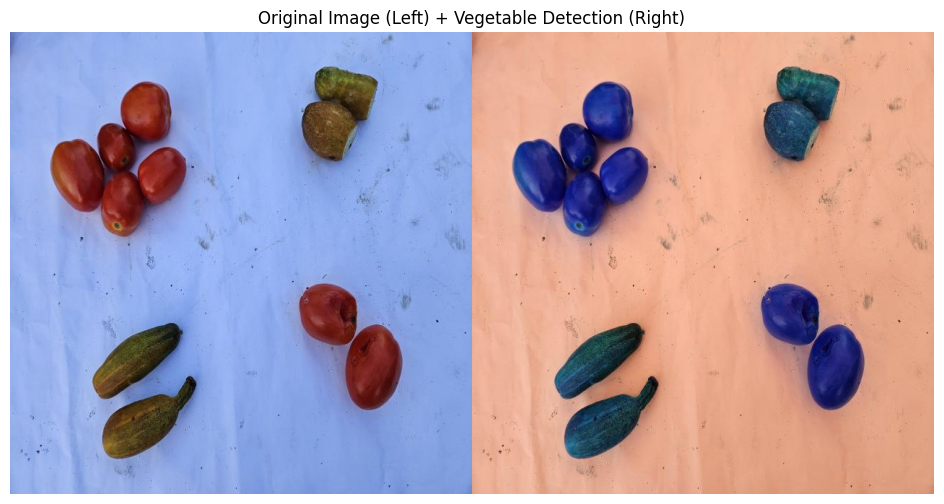

In [26]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image

def doMultiScaleCAM(modelPath, imagePath, modelIndexes=None):
    # Load YOLO model on CPU
    model = YOLO(modelPath)
    model = model.cpu()

    # Read image
    img = cv2.imread(imagePath)
    if img is None:
        raise FileNotFoundError(f"Image not found: {imagePath}")

    img = cv2.resize(img, (640, 640))

    # Convert BGR -> RGB for CAM
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = np.float32(rgb_img) / 255.0

    total_layers = len(model.model.model)
    print(f"Model has {total_layers} layers.")

    # Default last 3 layers if none provided
    if modelIndexes is None:
        modelIndexes = [total_layers - 3, total_layers - 2, total_layers - 1]
    else:
        modelIndexes = [i for i in modelIndexes if 0 <= i < total_layers]

    print(f"Using target layers at indices: {modelIndexes}")

    # Handle tuple outputs in CAM
    def reshape_transform(tensor_or_tuple):
        if isinstance(tensor_or_tuple, tuple):
            return tensor_or_tuple[0]
        return tensor_or_tuple

    # Generate CAMs
    for i in modelIndexes:
        target_layers = [model.model.model[i]]
        cam = EigenCAM(model, target_layers, task='od', reshape_transform=reshape_transform)
        grayscale_cam = cam(img_norm)[0, :, :]
        cam_image = show_cam_on_image(img_norm, grayscale_cam, use_rgb=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(cam_image)
        plt.axis('off')
        plt.title(f'CAM from layer {i}')
        plt.show()

    # Run detection on RGB image
    results = model(rgb_img, conf=0.1, iou=0.4)[0]

    # Filter Vegetable class (class_id 0)
    vegetable_class_id = 0  # adjust if needed
    filtered_boxes = [box for box in results.boxes if int(box.cls.item()) == vegetable_class_id]
    results.boxes = filtered_boxes

    # Plot filtered detection
    res_img = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

    # Combine original and result images horizontally
    combined = np.hstack((rgb_img, res_img))

    # Display inline
    plt.figure(figsize=(12, 6))
    plt.imshow(combined)
    plt.axis('off')
    plt.title("Original Image (Left) + Vegetable Detection (Right)")
    plt.show()

    return Image.fromarray(combined)


# ================= Usage Example =================
result_img = doMultiScaleCAM(
    str(WORK/"yolov11_train"/"weights/best.pt"),
    "/kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Multiclass_Vegetable_24_jpg.rf.8d34a92f30203f87046a973ccb024137.jpg"
)
